<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>HIERARCHICAL CLUSTER  </h2>
</div>

- Clustering is unsupervised Learning
- Clustering means grouping of objects based on the information found in the data, describing the objects or their relationship.
- Clustering is automatic classification. Here data will be unstructured or unlabelled data.
- Elbow curve, Distoration(Within cluster sum of square -WCSS) vs no of cluster to identify final no of cluster in model, some time Dendogram used to find K.
- In Agglomaritive, no centroid concept and in that fit_predict is there but just predict is not there 
- The clustering technique can be very handy when it comes to unlabeled data. Since most of the data in the real-world is unlabeled and annotating the data has higher costs, clustering techniques can be used to label unlabeled data.




##### Types Of Clustering			
    > 1.Exclusive Clustering(K-Mean Clustering)		
            - Here data item/points belongs to one cluster exclusively.	
    > 2. Overlapping Clustering(Fuzzy C-Mean cluster)	
            - Here data item/points belongs to more than one cluster.	
    > 3.Hierarchical Clustering(1. Agglomerative Clustering:2. Division Clustering:)
            - When 2 cluster will have parent-child relationship, or tree like structure, then its called Hierarchial cluster.	Dendogram or Tree like structure will be build
            
            


- affinity : Metric used to compute the linkage. Can be {“euclidean”, “l1”, “l2”, “manhattan”, “cosine”, or ‘precomputed’.} If linkage is “ward”, only “euclidean” is accepted.

- linkage : {“ward”, “complete”, “average”, “single”}, , optional (default=”ward”)
Which linkage criterion to use.

- ward minimizes the variance of the clusters being merged.

- average uses the average of the distances of each feature of the two sets.

- complete or maximum linkage uses the maximum distances between all features of the two sets.

- single uses the minimum of the distances between all observations of the two sets.


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

> We have Movie metadata, cluster these movie based on first two columns of facebook likes 
- 1) director_facebook_likes 
- 2) actor_3_facebook_likes

##  1. Import all Librariy

In [2]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

In [5]:
plt.rcParams['figure.figsize'] = (5,5)
plt.style.use('ggplot')
#importing the dataset
data = pd.read_csv(r'..\Dataset\movie_metadata1.csv')
data.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723,178,0,855,Joel David Moore,1000,760505847,Action|Adventure|Fantasy|Sci-Fi,...,3054,English,USA,PG-13,237000000,2009,936,7.9,1.78,33000
1,Color,Gore Verbinski,302,169,563,1000,Orlando Bloom,40000,309404152,Action|Adventure|Fantasy,...,1238,English,USA,PG-13,300000000,2007,5000,7.1,2.35,0
2,Color,Sam Mendes,602,148,0,161,Rory Kinnear,11000,200074175,Action|Adventure|Thriller,...,994,English,UK,PG-13,245000000,2015,393,6.8,2.35,85000
3,Color,Christopher Nolan,813,164,22000,23000,Christian Bale,27000,448130642,Action|Thriller,...,2701,English,USA,PG-13,250000000,2012,23000,8.5,2.35,164000
4,49,Doug Walker,49,49,131,49,Rob Walker,131,49,Documentary,...,49,49,49,49,49,49,12,7.1,49.00,0


## 2. Data Exploration

In [6]:
f1 = data['budget'].values
f2 = data['gross'].values
#Taking only sample for dendogram
fb = f1[0:10]
fg = f2[0:10]
X = np.array(list(zip(fb, fg)))
X

array([[237000000, 760505847],
       [300000000, 309404152],
       [245000000, 200074175],
       [250000000, 448130642],
       [       49,        49],
       [263700000,  73058679],
       [258000000, 336530303],
       [260000000, 200807262],
       [250000000, 458991599],
       [250000000, 301956980]], dtype=int64)

### 2.1 Dendogram with Linkage = 'ward'

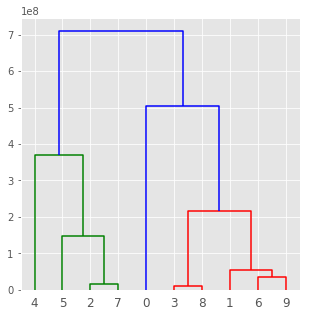

In [7]:
# define the linkage
# ward method or minimum increase of sum of squares MISSQ
#..SS12 -(SS1+SS2)
# 1. using linkage "ward"
Z = linkage(X, 'ward')
fig = plt.figure(figsize = (5,5))
dn = dendrogram(Z)
plt.show()

#Here X axis no as depends on no of items in sample input

### 2.2.1 CONCLUSION:

- If we draw a horizontal line that passes through longest distance without a horizontal line, we get 4 clusters 

### 2.2 Dendogram with Linkage = 'single'

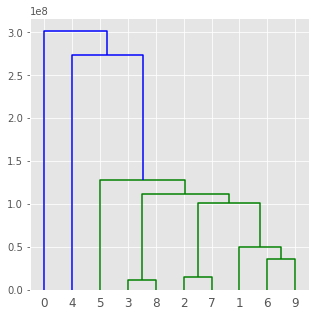

In [19]:
#Plot the dendogram as single
# 2. using linkage 'single'
Z = linkage(X, 'single')
fig = plt.figure(figsize = (5,5))
dn = dendrogram(Z)
plt.show()

## 3. Building Machine Learning - Agglomerative Cluster( Bottom Up algorithm)



- The next step is to import the class for clustering and call its fit_predict method to predict the clusters that each data point belongs to

In [12]:
from sklearn.cluster import AgglomerativeClustering

"""
In the code above we import the AgglomerativeClustering class from the "sklearn.cluster" library. 
The number of parameters is set to 2 using the n_clusters parameter 
while the affinity is set to "euclidean" (distance between the datapoints). 
Finally linkage parameter is set to "ward", which minimizes the variant between the clusters.
"""

cluster = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')  
cluster.fit_predict(X) 


array([0, 0, 1, 0, 1, 1, 0, 1, 0, 0], dtype=int64)

- Next we call the fit_predict method from the AgglomerativeClustering class variable cluster labels_. This method returns the names of the clusters that each data point belongs to

In [9]:
print(cluster.labels_)  

"""
The output is a one-dimensional array of 10 elements corresponding to the clusters assigned to our 10 data points.
"""

[0 0 1 0 1 1 0 1 0 0]


'\nThe output is a one-dimensional array of 10 elements corresponding to the clusters assigned to our 10 data points.\n'

## 4. Model Evaluation with Visualization

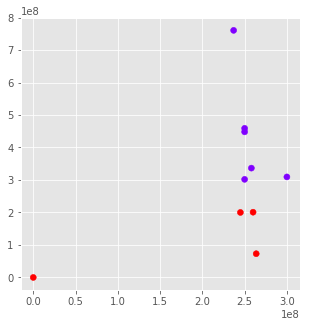

In [23]:
##PLOT THIS - method 1
plt.scatter(X[:,0],X[:,1], c=cluster.labels_, cmap='rainbow') 

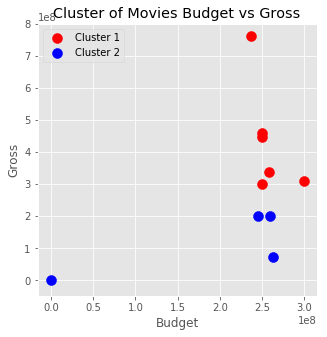

In [19]:
##PLOT THIS - method 2
"""
Explaining visualization code
In general: plt.scatter(X_axis_data, Y_axis_data, ....)
In our code: X contains input data (X_axis_data, Y_axis_data) and y_means contains output 
    i.e cluster ids(0 to 4)
X[y_kmeans == 0, 0] -> first '0' means the cluster id 0, second 0 is first column of X,
    it would return X co-ordinates for cluster 0
X[y_kmeans == 0, 1] -> '0' means the cluster id 0, 1 is second column of X that is y-axis 
    for scatter method

s = 100 is the size

"""

# In Agglomaritive, no centroid concept
plt.scatter(X[cluster.labels_ == 0, 0], X[cluster.labels_ == 0, 1],
           s=100, c='red', label='Cluster 1')
plt.scatter(X[cluster.labels_ == 1, 0], X[cluster.labels_ == 1, 1],
           s=100, c='blue', label='Cluster 2')

plt.title("Cluster of Movies Budget vs Gross")
plt.xlabel("Budget")
plt.ylabel("Gross")
plt.legend()
plt.show()

###  5. CONCLUSION

###### You can see points in two clusters where the first few points clustered together and the last few points clustered together.

- The clustering technique can be very handy when it comes to unlabeled data. Since most of the data in the real-world is unlabeled and annotating the data has higher costs, clustering techniques can be used to label unlabeled data.